# Baseline Function to Prove the Concept of Hardware-aware NAS

In [1]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

In [2]:
!pip install optuna
!pip install executorch
!pip install torch torchvision


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 37.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.0/13.0 MB 81.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.3/2.3 MB 92.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 85.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.2/7.2 MB 41.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 20.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 85.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 529.3/529.3 kB 51.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.7/59.7 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.7/40.7 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.1/73.1 k

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader # Import DataLoader

import optuna
import time
import os
from torchvision.models import resnet18, resnet34
device = "cuda" if torch.cuda.is_available() else "cpu"

In [4]:
transform = transforms.Compose([
    transforms.Resize(224),  # match ResNet input
    transforms.ToTensor(),
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)

valset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                      download=True, transform=transform)

100%|██████████| 170M/170M [00:13<00:00, 13.1MB/s]


In [5]:
from torchvision.models import resnet18

def build_model(num_classes=10):
    model = resnet18(weights=None)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

In [6]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    criterion = nn.CrossEntropyLoss()

    total_loss = 0

    for i, (x, y) in enumerate(loader):
        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        out = model(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        if i > 20:  # 🔥 limit for speed
            break

    return total_loss / (i + 1)

In [7]:
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x, y = x.to(device), y.to(device)
            out = model(x)
            pred = out.argmax(dim=1)

            correct += (pred == y).sum().item()
            total += y.size(0)

            if i > 10:
                break

    return correct / total

In [8]:
from torch.export import export
from executorch.exir import to_edge_transform_and_lower
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner

def export_to_executorch(model, device, trial_id):
    model = model.to("cpu")   # ✅ FORCE CPU
    model.eval()

    example_input = (torch.randn(1, 3, 224, 224),)  # ✅ CPU tensor

    try:
        from torch.export import export

        exported = export(model, example_input)

        from executorch.exir import to_edge_transform_and_lower
        from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner

        et_program = to_edge_transform_and_lower(
            exported,
            partitioner=[XnnpackPartitioner()]
        ).to_executorch()

        path = f"model_trial_{trial_id}.pte"

        with open(path, "wb") as f:
            f.write(et_program.buffer)

        size = os.path.getsize(path) / 1e6

        return True, size

    except Exception as e:
        print(f"Export failed: {e}")
        return False, None

def export_quantized_to_executorch(model, output_path):
    # The 'model' here is expected to be the quantized ExportedProgram from quantize_model_pt2e_xnnpack
    # It's already on CPU and in eval mode.

    try:
        # Re-export the quantized model to ensure it's in the expected format for to_edge_transform_and_lower
        example_input = (torch.randn(1, 3, 224, 224),) # Example input for re-export
        re_exported_model = export(model, example_input)

        et_program = to_edge_transform_and_lower(
            re_exported_model,
            partitioner=[XnnpackPartitioner()]
        ).to_executorch()

        with open(output_path, "wb") as f:
            f.write(et_program.buffer)

        size = os.path.getsize(output_path) / 1e6

        return output_path, size

    except Exception as e:
        print(f"Export of quantized model failed: {e}")
        return None, None

In [9]:
def measure_latency(model, device):
    model.eval()
    x = torch.randn(1, 3, 224, 224).to(device)

    start = time.time()

    with torch.no_grad():
        for _ in range(10):
            model(x)

    latency = (time.time() - start) / 10
    return latency

In [10]:
def export_stub(model, trial_id):
    path = f"model_{trial_id}.pt"
    torch.save(model.state_dict(), path)
    size = os.path.getsize(path) / 1e6  # MB
    return True, size

In [11]:
def objective(trial):
    device = "cuda" if torch.cuda.is_available() else "cpu"

    # --- Hyperparameters ---
    lr = trial.suggest_float("lr", 1e-4, 1e-2, log=True)
    batch_size = trial.suggest_categorical("batch_size", [32, 64])
    model_name = trial.suggest_categorical("model", ["resnet18", "resnet34"])
    epochs = trial.suggest_int("epochs", 1, 5)

    # --- Data ---
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(valset, batch_size=batch_size)

    # --- Model ---
    if model_name == "resnet18":
        model = resnet18()
    else:
        model = resnet34()

    model.fc = nn.Linear(model.fc.in_features, 10)
    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    # --- Train ---
    for _ in range(epochs):
        train_one_epoch(model, train_loader, optimizer, device)

    # --- Evaluate FP32 ---
    acc = evaluate(model, val_loader, device)

    # --- Proxy metrics ---
    latency = measure_latency(model, device)
    _, size = export_stub(model, trial.number)

    # --- Save info for stage 2 ---
    trial.set_user_attr("model", model_name)
    trial.set_user_attr("epochs", epochs)
    trial.set_user_attr("acc_fp32", acc)

    return acc, latency, size

In [12]:
study = optuna.create_study(directions=["maximize", "minimize", "minimize"])
study.optimize(objective, n_trials=20)

[I 2026-03-17 15:27:44,823] A new study created in memory with name: no-name-ef0ab3f5-0e19-480c-abeb-173292d3cbc6
[I 2026-03-17 15:27:50,578] Trial 0 finished with values: [0.1875, 0.01098334789276123, 44.805259] and parameters: {'lr': 0.006710384461610311, 'batch_size': 32, 'model': 'resnet18', 'epochs': 2}.
[I 2026-03-17 15:27:58,604] Trial 1 finished with values: [0.18619791666666666, 0.002588820457458496, 44.805259] and parameters: {'lr': 0.00010931251625043941, 'batch_size': 64, 'model': 'resnet18', 'epochs': 2}.
[I 2026-03-17 15:28:17,795] Trial 2 finished with values: [0.20833333333333334, 0.0045457124710083004, 85.299147] and parameters: {'lr': 0.007732832616094206, 'batch_size': 64, 'model': 'resnet34', 'epochs': 4}.
[I 2026-03-17 15:28:23,074] Trial 3 finished with values: [0.20833333333333334, 0.0025554180145263674, 44.805259] and parameters: {'lr': 0.000216076224222472, 'batch_size': 32, 'model': 'resnet18', 'epochs': 3}.
[I 2026-03-17 15:28:27,575] Trial 4 finished with va

In [13]:
best_trials = study.best_trials[:3]   # top 3 Pareto

In [14]:
trials = study.best_trials

for t in trials:
    print(
        t.user_attrs["model"],
        t.user_attrs["epochs"],
        t.values  # (acc, latency, size)
    )

resnet18 2 [0.24739583333333334, 0.002553582191467285, 44.805259]
resnet18 5 [0.3841145833333333, 0.0025207042694091798, 44.805899]


In [15]:
for t in best_trials:
    model_name = t.user_attrs["model"]
    epochs = t.user_attrs["epochs"]
    lr = t.params["lr"]
    batch_size = t.params["batch_size"]

    # rebuild model
    if model_name == "resnet18":
        model = resnet18()
    else:
        model = resnet34()

    model = model.to(device)

    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Re-initialize DataLoaders for each trial
    train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
    val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size)

    # retrain model (IMPORTANT)
    for _ in range(epochs):
        train_one_epoch(model, train_loader, optimizer, device)

    model.eval()

    success, size = export_to_executorch(model, "cpu", f"trained_{t.number}")

    print(f"Exported TRAINED model from Trial {t.number}")

Exported TRAINED model from Trial 7
Exported TRAINED model from Trial 11


In [16]:
for f in os.listdir():
    if f.endswith(".pte"):
        size = os.path.getsize(f) / 1e6
        print(f"{f}: {size:.2f} MB")

model_trial_trained_7.pte: 46.76 MB
model_trial_trained_11.pte: 46.76 MB


In [17]:
def simulate_deployment(model):
    model.eval()
    x = torch.randn(1, 3, 224, 224)

    with torch.no_grad():
        out = model(x)

    return out

In [18]:
import copy
import torch

from torch.export import export_for_training, export

from torchao.quantization.pt2e.quantize_pt2e import prepare_pt2e, convert_pt2e
from executorch.backends.xnnpack.quantizer.xnnpack_quantizer import (
    XNNPACKQuantizer,
    get_symmetric_quantization_config,
)
from executorch.exir import to_edge_transform_and_lower
from executorch.backends.xnnpack.partition.xnnpack_partitioner import XnnpackPartitioner

In [19]:
def calibrate_pt2e(prepared_model, calib_loader, num_batches=10):
    from torchao.quantization.pt2e import allow_exported_model_train_eval
    allow_exported_model_train_eval(prepared_model)
    prepared_model.eval()
    with torch.no_grad():
        for i, (x, _) in enumerate(calib_loader):
            x = x.to("cpu")
            prepared_model(x)
            if i + 1 >= num_batches:
                break

In [20]:
def build_model_from_name(model_name: str, num_classes: int = 10):
    if model_name == "resnet18":
        model = resnet18(weights=None)
    else:
        model = resnet34(weights=None)

    model.fc = torch.nn.Linear(model.fc.in_features, num_classes)
    return model


def retrain_trial_model(trial, train_loader, device):
    model_name = trial.user_attrs["model"]
    epochs = trial.user_attrs["epochs"]
    lr = trial.params["lr"]

    model = build_model_from_name(model_name).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    for _ in range(epochs):
        train_one_epoch(model, train_loader, optimizer, device)

    return model


def quantize_model_pt2e_xnnpack(model, calib_loader, num_calib_batches=10):
    # PT2E quantization is safest on CPU
    model = copy.deepcopy(model).to("cpu").eval()

    example_inputs = (torch.randn(1, 3, 224, 224),)

    # Export to training graph for PT2E prepare
    exported = export_for_training(model, example_inputs).module()

    quantizer = XNNPACKQuantizer().set_global(get_symmetric_quantization_config())

    prepared = prepare_pt2e(exported, quantizer)

    # Static calibration
    calibrate_pt2e(prepared, calib_loader, num_batches=num_calib_batches)

    quantized_model = convert_pt2e(prepared)

    # Apply allow_exported_model_train_eval to the final quantized model
    from torchao.quantization.pt2e import allow_exported_model_train_eval
    allow_exported_model_train_eval(quantized_model)

    quantized_model.eval()

    return quantized_model

In [21]:
def evaluate_cpu(model, loader):
    correct = 0
    total = 0

    with torch.no_grad():
        for i, (x, y) in enumerate(loader):
            x, y = x.to("cpu"), y.to("cpu")

            out = model(x)   # ✅ no .to(), no .eval()

            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += y.size(0)

            if i > 50:   # keep it short for now
                break

    return correct / total

In [22]:
best_trial = study.best_trials[0]

batch_size = best_trial.params["batch_size"]
train_loader = torch.utils.data.DataLoader(trainset, batch_size=batch_size, shuffle=True)
val_loader = torch.utils.data.DataLoader(valset, batch_size=batch_size, shuffle=False)

fp32_model = retrain_trial_model(
    best_trial,
    train_loader,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

fp32_acc = evaluate(
    fp32_model,
    val_loader,
    device="cuda" if torch.cuda.is_available() else "cpu"
)

# Calibration must match exported shape assumptions
calib_loader = torch.utils.data.DataLoader(trainset, batch_size=1, shuffle=True)

int8_model = quantize_model_pt2e_xnnpack(fp32_model, calib_loader)

# Sanity check first
print("INT8 model type:", type(int8_model))
x_test = torch.randn(1, 3, 224, 224)
with torch.no_grad():
    y_test = int8_model(x_test)
print("INT8 forward shape:", y_test.shape)

# Evaluate with batch_size=1 to avoid guard mismatch
val_loader_q = torch.utils.data.DataLoader(valset, batch_size=1, shuffle=False)
int8_acc = evaluate_cpu(int8_model, val_loader_q)

print("FP32 acc:", fp32_acc)
print("INT8 acc:", int8_acc)

INT8 model type: <class 'torch.fx.graph_module.GraphModule.__new__.<locals>.GraphModuleImpl'>
INT8 forward shape: torch.Size([1, 10])
FP32 acc: 0.2526041666666667
INT8 acc: 0.19230769230769232


In [23]:
pte_path, q_size_mb = export_quantized_to_executorch(int8_model, "quantized.pte")

print("Quantized size: (mb)", q_size_mb)

Quantized size: (mb) 11.215656


In [24]:
def measure_latency(model):
    model = model.to("cpu").eval()

    x = torch.randn(1, 3, 224, 224)

    # warmup
    for _ in range(10):
        _ = model(x)

    import time
    start = time.time()

    for _ in range(50):
        _ = model(x)

    end = time.time()

    latency = (end - start) / 50
    return latency

In [25]:
def measure_latency(model):
    model = model.to("cpu").eval()

    x = torch.randn(1, 3, 224, 224)

    # warmup
    for _ in range(10):
        _ = model(x)

    import time
    start = time.time()

    for _ in range(50):
        _ = model(x)

    end = time.time()

    latency = (end - start) / 50
    return latency

In [26]:
results = []

for t in best_trials:
    print(f"\n=== Re-evaluating Trial {t.number} ===")

    # rebuild loaders
    batch_size = t.params["batch_size"]
    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(valset, batch_size=1, shuffle=False)  # IMPORTANT

    # rebuild model
    model = build_model_from_name(t.user_attrs["model"]).to("cuda" if torch.cuda.is_available() else "cpu")

    optimizer = optim.Adam(model.parameters(), lr=t.params["lr"])

    # retrain
    for _ in range(t.user_attrs["epochs"]):
        train_one_epoch(model, train_loader, optimizer, "cuda" if torch.cuda.is_available() else "cpu")

    # FP32 accuracy
    acc_fp32 = evaluate(model, val_loader, "cuda" if torch.cuda.is_available() else "cpu")

    # --- Quantization ---
    calib_loader = DataLoader(trainset, batch_size=1, shuffle=True)
    int8_model = quantize_model_pt2e_xnnpack(model, calib_loader)

    # INT8 accuracy
    acc_int8 = evaluate_cpu(int8_model, val_loader)

    # Export quantized
    pte_path, size_int8 = export_quantized_to_executorch(int8_model, f"trial_{t.number}_int8.pte")

    print(f"""
    Trial {t.number}
    FP32 acc: {acc_fp32:.3f}
    INT8 acc: {acc_int8:.3f}
    INT8 size: {size_int8:.2f} MB
    """)

    results.append({
        "trial": t.number,
        "model": t.user_attrs["model"],
        "acc_fp32": acc_fp32,
        "acc_int8": acc_int8,
        "size_int8": size_int8
    })


=== Re-evaluating Trial 7 ===

    Trial 7
    FP32 acc: 0.500
    INT8 acc: 0.346
    INT8 size: 11.22 MB
    

=== Re-evaluating Trial 11 ===

    Trial 11
    FP32 acc: 0.417
    INT8 acc: 0.442
    INT8 size: 11.22 MB
    


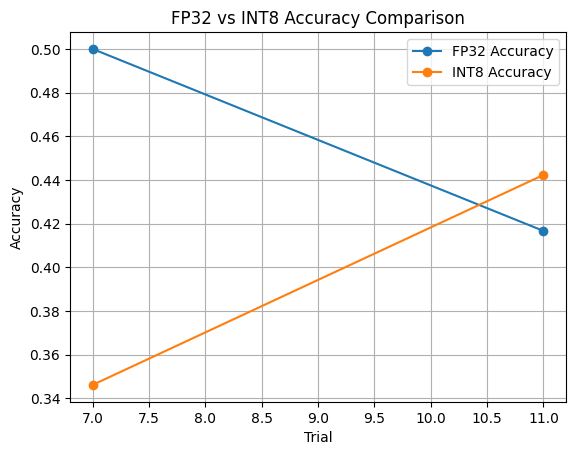

In [27]:
import matplotlib.pyplot as plt

trials = [r["trial"] for r in results]
acc_fp32 = [r["acc_fp32"] for r in results]
acc_int8 = [r["acc_int8"] for r in results]

plt.figure()

plt.plot(trials, acc_fp32, marker='o', label="FP32 Accuracy")
plt.plot(trials, acc_int8, marker='o', label="INT8 Accuracy")

plt.xlabel("Trial")
plt.ylabel("Accuracy")
plt.title("FP32 vs INT8 Accuracy Comparison")

plt.legend()
plt.grid()
plt.show()

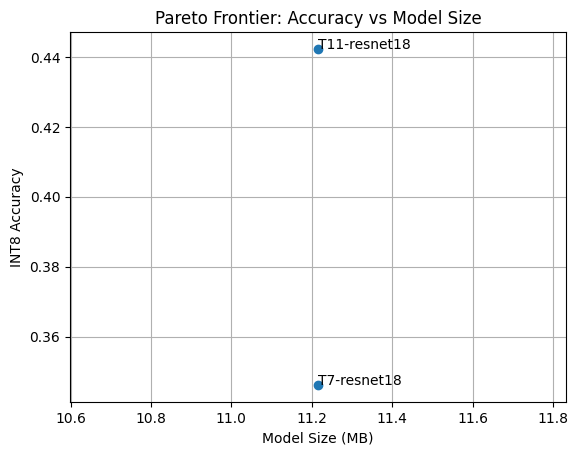

In [28]:
import matplotlib.pyplot as plt

# Extract data
sizes = [r["size_int8"] for r in results]
accs = [r["acc_int8"] for r in results]
labels = [f'T{r["trial"]}-{r["model"]}' for r in results]

plt.figure()

plt.scatter(sizes, accs)

# Annotate points
for i, label in enumerate(labels):
    plt.annotate(label, (sizes[i], accs[i]))

plt.xlabel("Model Size (MB)")
plt.ylabel("INT8 Accuracy")
plt.title("Pareto Frontier: Accuracy vs Model Size")

plt.grid()
plt.show()